# True Vanilla CVAE Sampling for VTaC Utility Evaluation

This notebook trains a strict vanilla CVAE baseline and saves synthetic true-alarm samples in the same format expected by the utility-evaluation notebook.

Definition used here:
- single encoder over zero-filled 4-channel waveform
- condition vector `c = [label, m_ECG1, m_ECG2, m_PPG, m_ABP]`
- decoder conditioned on `c`
- loss = masked reconstruction MSE + beta KL only
- no wavelet/STFT loss, no ECG-pulse/correlation loss, no classifier/perceptual loss, no attention, no multi-branch fusion


In [11]:
# ============================================================
# 0. Setup
# ============================================================

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('Drive mount skipped:', e)

import os
import random
import json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cuda


In [12]:
# ============================================================
# 1. Paths
# ============================================================

PROJECT_DRIVE = '/content/drive/MyDrive/vtac_project'

DATA_DIR_CANDIDATES = [
    f'{PROJECT_DRIVE}/data/processed',
    '/content/drive/MyDrive/vtac_preprocessed_10s_v2',
]

def first_existing_dir(paths):
    for p in paths:
        if os.path.isdir(p):
            return p
    # keep the first candidate so the failure message is explicit later
    return paths[0]

DATA_DIR = first_existing_dir(DATA_DIR_CANDIDATES)

TRAIN_PT = f'{DATA_DIR}/train_10s.pt'
VAL_PT   = f'{DATA_DIR}/val_10s.pt'
TEST_PT  = f'{DATA_DIR}/test_10s.pt'

# Standardized output consumed by the fixed eval notebook.
OUT_DIR = f'{PROJECT_DRIVE}/outputs/true_vanilla_cvae'
os.makedirs(OUT_DIR, exist_ok=True)

CKPT_PATH = f'{OUT_DIR}/true_vanilla_cvae_best.pt'
SYN_PATH  = f'{OUT_DIR}/generated_true_true_vanilla.pt'

print('DATA_DIR:', DATA_DIR)
print('OUT_DIR:', OUT_DIR)
print('TRAIN_PT:', TRAIN_PT, 'exists=', os.path.exists(TRAIN_PT))
print('VAL_PT  :', VAL_PT,   'exists=', os.path.exists(VAL_PT))
print('TEST_PT :', TEST_PT,  'exists=', os.path.exists(TEST_PT))
print('SYN_PATH:', SYN_PATH)


DATA_DIR: /content/drive/MyDrive/vtac_project/data/processed
OUT_DIR: /content/drive/MyDrive/vtac_project/outputs/true_vanilla_cvae
TRAIN_PT: /content/drive/MyDrive/vtac_project/data/processed/train_10s.pt exists= True
VAL_PT  : /content/drive/MyDrive/vtac_project/data/processed/val_10s.pt exists= True
TEST_PT : /content/drive/MyDrive/vtac_project/data/processed/test_10s.pt exists= True
SYN_PATH: /content/drive/MyDrive/vtac_project/outputs/true_vanilla_cvae/generated_true_true_vanilla.pt


In [13]:
# ============================================================
# 2. Load preprocessed data
# ============================================================

def safe_load(path):
    try:
        return torch.load(path, map_location='cpu', weights_only=False)
    except TypeError:
        return torch.load(path, map_location='cpu')

def load_split(path):
    d = safe_load(path)
    X = d['X'].float()
    y = d['y'].long()
    if 'm_channel' in d:
        m = d['m_channel'].float()
    elif 'm' in d:
        m = d['m'].float()
    else:
        raise KeyError("Expected mask key 'm_channel' or 'm'.")

    print(os.path.basename(path))
    print('  X:', tuple(X.shape))
    print('  y:', torch.bincount(y, minlength=2).tolist())
    print('  m avail:', m.sum(0).long().tolist())
    return X, y, m, d

X_train, y_train, m_train, train_meta = load_split(TRAIN_PT)
X_val,   y_val,   m_val,   val_meta   = load_split(VAL_PT)
X_test,  y_test,  m_test,  test_meta  = load_split(TEST_PT)

CHANNELS = train_meta.get('channels', ['ECG1', 'ECG2', 'PPG', 'ABP'])
SEQ_LEN = X_train.shape[-1]
X_CHANNELS = X_train.shape[1]
C_DIM = 1 + X_CHANNELS
LATENT_DIM = 128

assert X_CHANNELS == 4, f'Expected 4 channels, got {X_CHANNELS}'
assert C_DIM == 5, f'Expected c_dim=5, got {C_DIM}'
print('CHANNELS:', CHANNELS)
print('SEQ_LEN:', SEQ_LEN)


train_10s.pt
  X: (3901, 4, 2500)
  y: [2754, 1147]
  m avail: [3901, 3901, 3572, 1393]
val_10s.pt
  X: (481, 4, 2500)
  y: [341, 140]
  m avail: [481, 481, 445, 171]
test_10s.pt
  X: (465, 4, 2500)
  y: [328, 137]
  m avail: [465, 465, 425, 171]
CHANNELS: ['ECG1', 'ECG2', 'PPG', 'ABP']
SEQ_LEN: 2500


In [14]:
# ============================================================
# 3. Dataset
# condition: c = [label, m_ECG1, m_ECG2, m_PPG, m_ABP]
# ============================================================

def make_condition(y, m):
    return torch.cat([y.float().unsqueeze(1), m.float()], dim=1)

c_train = make_condition(y_train, m_train)
c_val   = make_condition(y_val, m_val)
c_test  = make_condition(y_test, m_test)

BATCH_SIZE = 64
NUM_WORKERS = 2

train_loader = DataLoader(
    TensorDataset(X_train, c_train, m_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=False,
)

val_loader = DataLoader(
    TensorDataset(X_val, c_val, m_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=False,
)


In [15]:
# ============================================================
# 4. True Vanilla CVAE
# ============================================================

class TrueVanillaCVAE(nn.Module):
    def __init__(self, x_channels=4, c_dim=5, latent_dim=128, seq_len=2500):
        super().__init__()
        self.x_channels = x_channels
        self.c_dim = c_dim
        self.latent_dim = latent_dim
        self.seq_len = seq_len

        # Vanilla conditioning: concatenate c as constant channels along time.
        self.encoder = nn.Sequential(
            nn.Conv1d(x_channels + c_dim, 32, kernel_size=9, stride=2, padding=4),
            nn.BatchNorm1d(32),
            nn.SiLU(),

            nn.Conv1d(32, 64, kernel_size=9, stride=2, padding=4),
            nn.BatchNorm1d(64),
            nn.SiLU(),

            nn.Conv1d(64, 128, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(128),
            nn.SiLU(),

            nn.Conv1d(128, 128, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(128),
            nn.SiLU(),

            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )

        self.enc_head = nn.Sequential(
            nn.Linear(128, 256),
            nn.SiLU(),
        )
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        self.dec_len = 313  # 313 * 2 * 2 * 2 = 2504, cropped to 2500
        self.dec_channels = 256

        self.fc_dec = nn.Sequential(
            nn.Linear(latent_dim + c_dim, 512),
            nn.SiLU(),
            nn.Linear(512, self.dec_channels * self.dec_len),
            nn.SiLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(128),
            nn.SiLU(),

            nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(64),
            nn.SiLU(),

            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(32),
            nn.SiLU(),

            nn.Conv1d(32, x_channels, kernel_size=9, padding=4),
        )

    def encode(self, x, c, m):
        # Missing channels are zero-filled before entering the single encoder.
        x_in = x * m.unsqueeze(-1)
        c_map = c.unsqueeze(-1).expand(-1, -1, x_in.shape[-1])
        h = torch.cat([x_in, c_map], dim=1)
        h = self.encoder(h)
        h = self.enc_head(h)
        mu = self.fc_mu(h)
        logvar = torch.clamp(self.fc_logvar(h), -10, 10)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c, m=None):
        h = torch.cat([z, c], dim=1)
        h = self.fc_dec(h)
        h = h.view(z.size(0), self.dec_channels, self.dec_len)
        x_hat = self.decoder(h)[:, :, :self.seq_len]
        if m is not None:
            x_hat = x_hat * m.unsqueeze(-1)
        return x_hat

    def forward(self, x, c, m):
        mu, logvar = self.encode(x, c, m)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z, c, m)
        return x_hat, mu, logvar

    @torch.no_grad()
    def sample_prior(self, c, m, z_scale=1.0):
        z = torch.randn(c.size(0), self.latent_dim, device=c.device) * z_scale
        return self.decode(z, c, m)


In [16]:
# ============================================================
# 5. Vanilla CVAE loss: masked reconstruction + KL only
# ============================================================

def masked_recon_loss(x, x_hat, m, eps=1e-8):
    mask = m.to(x.dtype).unsqueeze(-1)
    return ((x - x_hat) ** 2 * mask).sum() / (mask.sum() * x.shape[-1] + eps)

def kl_loss(mu, logvar):
    logvar = torch.clamp(logvar, -10, 10)
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

def cvae_loss(x, x_hat, mu, logvar, m, beta=1e-3):
    recon = masked_recon_loss(x, x_hat, m)
    kl = kl_loss(mu, logvar)
    loss = recon + beta * kl
    return loss, recon, kl


In [17]:
# ============================================================
# 6. Train
# ============================================================

EPOCHS = 60
BETA = 1e-3
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 12


def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    n = 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for x, c, m in loader:
            x = x.to(device).float()
            c = c.to(device).float()
            m = m.to(device).float()

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            x_hat, mu, logvar = model(x, c, m)
            loss, recon, kl = cvae_loss(x, x_hat, mu, logvar, m, beta=BETA)

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            bs = x.size(0)
            total_loss += loss.item() * bs
            total_recon += recon.item() * bs
            total_kl += kl.item() * bs
            n += bs

    return {
        'loss': total_loss / n,
        'recon': total_recon / n,
        'kl': total_kl / n,
    }

model = TrueVanillaCVAE(
    x_channels=X_CHANNELS,
    c_dim=C_DIM,
    latent_dim=LATENT_DIM,
    seq_len=SEQ_LEN,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

history = {'train': [], 'val': []}
best_val = float('inf')
best_epoch = None
bad_epochs = 0

for ep in range(1, EPOCHS + 1):
    tr = run_epoch(model, train_loader, optimizer)
    va = run_epoch(model, val_loader, None)
    scheduler.step()

    history['train'].append(tr)
    history['val'].append(va)

    if va['loss'] < best_val:
        best_val = va['loss']
        best_epoch = ep
        bad_epochs = 0
        torch.save({
            'epoch': ep,
            'best_val': best_val,
            'model_state_dict': model.state_dict(),
            'history': history,
            'config': {
                'model': 'TrueVanillaCVAE',
                'model_family': 'single_encoder_conditional_vae',
                'loss': 'masked_mse_plus_beta_kl_only',
                'latent_dim': LATENT_DIM,
                'c_dim': C_DIM,
                'seq_len': SEQ_LEN,
                'beta': BETA,
                'channels': CHANNELS,
                'seed': SEED,
                'data_dir': DATA_DIR,
            },
        }, CKPT_PATH)
    else:
        bad_epochs += 1

    if ep == 1 or ep % 5 == 0:
        print(
            f"Ep {ep:03d} | "
            f"train loss={tr['loss']:.4f}, recon={tr['recon']:.4f}, kl={tr['kl']:.4f} | "
            f"val loss={va['loss']:.4f}, recon={va['recon']:.4f}, kl={va['kl']:.4f} | "
            f"best ep={best_epoch}, best val={best_val:.4f}"
        )

    if bad_epochs >= PATIENCE:
        print(f'Early stopping at epoch {ep}; best epoch={best_epoch}, best val={best_val:.4f}')
        break

print('best epoch:', best_epoch)
print('best val:', best_val)
print('saved:', CKPT_PATH)


Ep 001 | train loss=0.9902, recon=0.9900, kl=0.2122 | val loss=0.9851, recon=0.9850, kl=0.0805 | best ep=1, best val=0.9851
Ep 005 | train loss=0.9818, recon=0.9817, kl=0.0940 | val loss=0.9836, recon=0.9835, kl=0.1162 | best ep=3, best val=0.9835
Ep 010 | train loss=0.9804, recon=0.9803, kl=0.0678 | val loss=0.9824, recon=0.9823, kl=0.0622 | best ep=10, best val=0.9824
Ep 015 | train loss=0.9795, recon=0.9794, kl=0.1006 | val loss=0.9820, recon=0.9819, kl=0.0719 | best ep=14, best val=0.9818
Ep 020 | train loss=0.9794, recon=0.9793, kl=0.1109 | val loss=0.9824, recon=0.9822, kl=0.1692 | best ep=16, best val=0.9815
Ep 025 | train loss=0.9777, recon=0.9776, kl=0.1305 | val loss=0.9826, recon=0.9824, kl=0.1505 | best ep=16, best val=0.9815
Early stopping at epoch 28; best epoch=16, best val=0.9815
best epoch: 16
best val: 0.9815097302508206
saved: /content/drive/MyDrive/vtac_project/outputs/true_vanilla_cvae/true_vanilla_cvae_best.pt


In [18]:
import os, glob

print("OUT_DIR:", OUT_DIR)
print("CKPT_PATH:", CKPT_PATH)
print("OUT_DIR exists:", os.path.exists(OUT_DIR))
print("CKPT exists:", os.path.exists(CKPT_PATH))

print("\nfiles in OUT_DIR:")
for p in glob.glob(os.path.join(OUT_DIR, "*")):
    print(p)

OUT_DIR: /content/drive/MyDrive/vtac_project/outputs/true_vanilla_cvae
CKPT_PATH: /content/drive/MyDrive/vtac_project/outputs/true_vanilla_cvae/true_vanilla_cvae_best.pt
OUT_DIR exists: True
CKPT exists: True

files in OUT_DIR:
/content/drive/MyDrive/vtac_project/outputs/true_vanilla_cvae/true_vanilla_cvae_best.pt


In [19]:
# ============================================================
# 7. Load best checkpoint and generate synthetic true alarms
# ============================================================

ckpt = safe_load(CKPT_PATH)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print('loaded:', CKPT_PATH)
print('best epoch:', ckpt.get('epoch'), 'best val:', ckpt.get('best_val'))

@torch.no_grad()
def generate_true_alarms(model, true_masks, n_samples, z_scale=1.0, batch_size=128, seed=42):
    model.eval()
    gen = torch.Generator(device='cpu')
    gen.manual_seed(seed)

    idx = torch.randint(0, len(true_masks), (n_samples,), generator=gen)
    m_syn = true_masks[idx].float()

    y_syn = torch.ones(n_samples, dtype=torch.long)
    c_syn = make_condition(y_syn, m_syn)

    outs = []
    for s in range(0, n_samples, batch_size):
        cb = c_syn[s:s+batch_size].to(device).float()
        mb = m_syn[s:s+batch_size].to(device).float()
        xb = model.sample_prior(cb, mb, z_scale=z_scale)
        xb = xb * mb.unsqueeze(-1)
        outs.append(xb.cpu())

    X_syn = torch.cat(outs, dim=0)
    return X_syn, y_syn, m_syn

n_false = int((y_train == 0).sum().item())
n_true = int((y_train == 1).sum().item())
n_gen = max(n_false - n_true, 0)
true_mask_pool = m_train[y_train == 1]

print('false:', n_false)
print('true:', n_true)
print('generate:', n_gen)
print('true mask pool:', tuple(true_mask_pool.shape))

X_syn, y_syn, m_syn = generate_true_alarms(
    model,
    true_masks=true_mask_pool,
    n_samples=n_gen,
    z_scale=1.0,
    batch_size=128,
    seed=SEED + 2026,
)

syn_payload = {
    'X_syn': X_syn,
    'y_syn': y_syn,
    'm_syn': m_syn,
    'method': 'true_vanilla_cvae_recon_kl',
    'model_family': 'single_encoder_conditional_vae',
    'loss': 'masked_mse_plus_beta_kl_only',
    'source_ckpt': CKPT_PATH,
    'best_epoch': ckpt.get('epoch'),
    'best_val': ckpt.get('best_val'),
    'seed': SEED,
    'sample_seed': SEED + 2026,
    'z_scale': 1.0,
    'channels': CHANNELS,
    'window_sec': train_meta.get('window_sec', [-10, 0]),
    'fs': train_meta.get('fs', train_meta.get('sampling_freq', 250)),
    'data_dir': DATA_DIR,
}

torch.save(syn_payload, SYN_PATH)

print('X_syn:', tuple(X_syn.shape))
print('y_syn:', tuple(y_syn.shape), torch.bincount(y_syn, minlength=2).tolist())
print('m_syn:', tuple(m_syn.shape))
print('std:', float(X_syn.std()))
print('saved:', SYN_PATH)


loaded: /content/drive/MyDrive/vtac_project/outputs/true_vanilla_cvae/true_vanilla_cvae_best.pt
best epoch: 16 best val: 0.9815097302508206
false: 2754
true: 1147
generate: 1607
true mask pool: (1147, 4)
X_syn: (1607, 4, 2500)
y_syn: (1607,) [0, 1607]
m_syn: (1607, 4)
std: 0.024274494498968124
saved: /content/drive/MyDrive/vtac_project/outputs/true_vanilla_cvae/generated_true_true_vanilla.pt


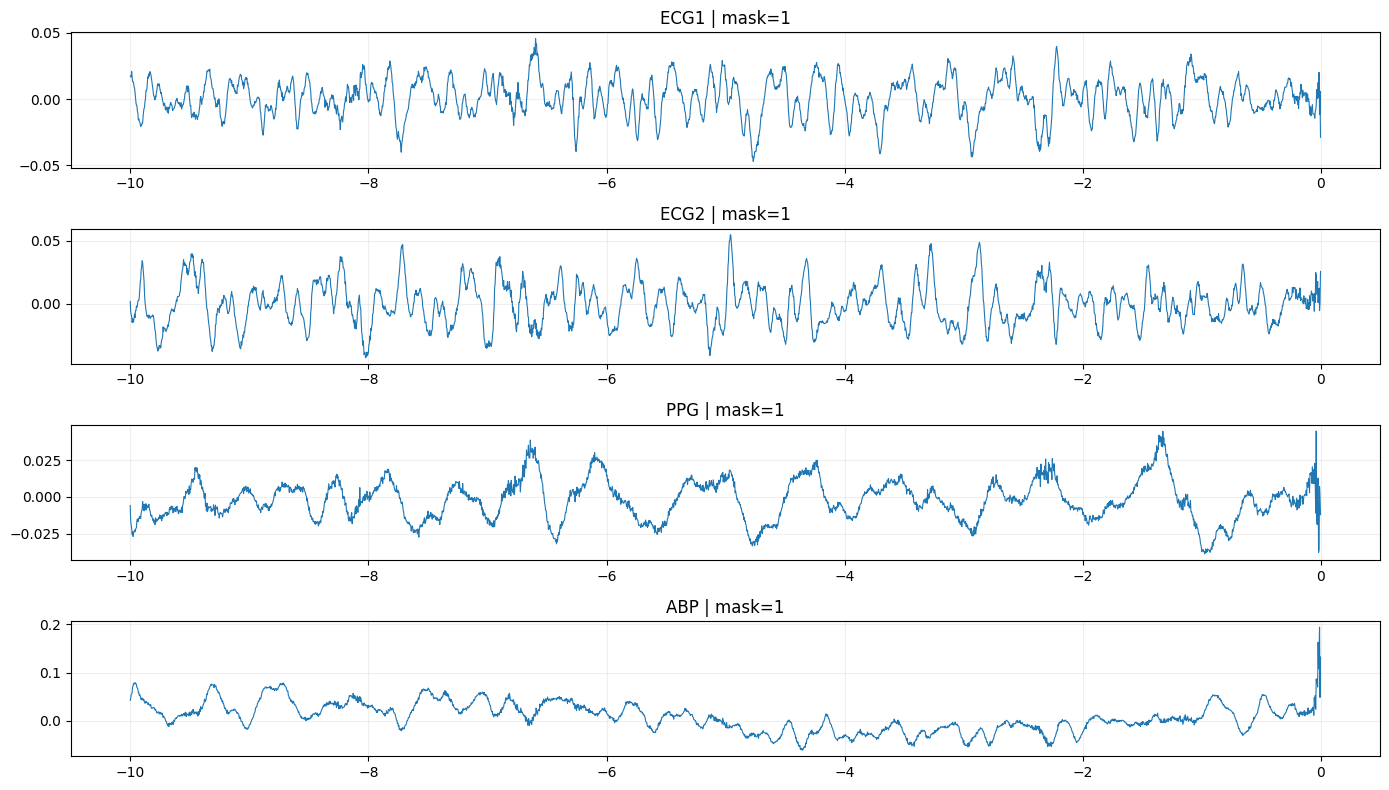

In [20]:
# ============================================================
# 8. Quick generated waveform plot
# ============================================================

def plot_generated(X_syn, m_syn, idx=0):
    x = X_syn[idx].numpy()
    m = m_syn[idx].numpy()
    t = np.arange(x.shape[-1]) / 250 - 10.0

    plt.figure(figsize=(14, 8))
    for i, ch in enumerate(CHANNELS):
        plt.subplot(4, 1, i + 1)
        plt.plot(t, x[i], linewidth=0.8)
        plt.title(f'{ch} | mask={int(m[i])}')
        plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

if len(X_syn) > 0:
    plot_generated(X_syn, m_syn, idx=0)
